# Complete bar chart generator

This notebook follows the structure of `line_generator_complete_weighted_v2.ipynb`, but generates and tests classic bar charts. It includes:

- all bar-chart parameters from `Bar charts.xlsx`,
- sampling weights derived from the spreadsheet rows,
- integrated Matplotlib, Seaborn/Matplotlib, and Altair renderers,
- the original single-notebook bar chart code preserved as reference cells,
- example generation and parameter-coverage testing.


In [26]:

from __future__ import annotations

import seaborn
import importlib
import json
import math
import random
import re
import shutil
import string
import subprocess
import sys
from datetime import datetime
from pathlib import Path
from uuid import uuid4

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import colors as mcolors


def _optional_import(module_name):
    try:
        return importlib.import_module(module_name)
    except Exception:
        return None


def install_package(pip_name: str):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])


def ensure_module(module_name: str, pip_name: str | None = None):
    module = _optional_import(module_name)
    if module is not None:
        return module
    install_package(pip_name or module_name)
    return importlib.import_module(module_name)


sns = _optional_import('seaborn')
alt = _optional_import('altair')
go = _optional_import('plotly.graph_objects')

try:
    from IPython.display import display
except Exception:
    display = None


In [3]:
PROJECT = Path.cwd().resolve()
OUTPUTS = PROJECT / "outputs"
GENERATED = OUTPUTS / "generated"
GENERATED.mkdir(parents=True, exist_ok=True)

# Same output pattern as the line-chart notebook, but the parameter tests now write
# directly into the barplots folder so barplots/images/<library>/ contains one
# generated file per tested parameter option.
BAR_OUT_ROOT = GENERATED / "barplots"
BAR_TEST_OUT_ROOT = BAR_OUT_ROOT


## 1. Style schema

In [4]:
PARAMETER_HEADERS = ['Charts', 'Vertical (yes)', 'Title (yes)', 'Title (centered: 1/left: 2/right: 3)', 'Title black', 'Title size average', 'Title size large', 'Subtitle (yes)', 'Outline chart (yes)', "Legend: ('left', 'right', 'top', 'bottom', 'top-left', 'top-right')", 'legend title', 'Legend title color (yes)', 'Legend outline (yes)', 'Gridlines (yes)', 'H&V gridlines', 'X Labels horizontal', 'X labels diagonal', 'X labels vertical', 'Y labels horizontal', 'Y labels diagonal', 'Y labels vertical', 'Labels colored (yes)', 'Direct labeling (1: no quantitative axis labels, 2: labels but still axis labels)', 'Direct labeling (base: 0, outside: 1, center: 2)', 'Aspect ratio (square: 0, more horizontal: 1, more vertical: 2)', 'Samples (1-10: 0, 11-20:1, 21-30: 2, ...)', 'Colored bars (yes)', 'Rounded corners', 'Outline bars', 'Background no white', 'Ticks (0: no, 1: X, 2, X & Y, 3: Y)']
EXCEL_PARAMETER_COUNTS = {'Vertical (yes)': {1.0: 74, 0.0: 26}, 'Title (yes)': {1.0: 61, 0.0: 39}, 'Title (centered: 1/left: 2/right: 3)': {1.0: 48, 0.0: 39, 2.0: 13}, 'Title black': {1.0: 36, 0.0: 64}, 'Title size average': {1.0: 49, 0.0: 51}, 'Title size large': {0.0: 88, 1.0: 12}, 'Subtitle (yes)': {0.0: 96, 1.0: 4}, 'Outline chart (yes)': {0.0: 90, 1.0: 10}, "Legend: ('left', 'right', 'top', 'bottom', 'top-left', 'top-right')": {'no legend': 53, 'middle-right': 3, 0.0: 38, 'top-center': 1, 'top-right': 3, 'top-left': 1, 'bottom-center': 1}, 'legend title': {0.0: 99, 1.0: 1}, 'Legend title color (yes)': {0.0: 100}, 'Legend outline (yes)': {0.0: 98, 1.0: 2}, 'Gridlines (yes)': {1.0: 52, 0.0: 48}, 'H&V gridlines': {0.0: 87, 1.0: 13}, 'X Labels horizontal': {1.0: 92, 0.0: 8}, 'X labels diagonal': {0.0: 96, 1.0: 4}, 'X labels vertical': {0.0: 99, 1.0: 1}, 'Y labels horizontal': {1.0: 98, 0.0: 2}, 'Y labels diagonal': {0.0: 100}, 'Y labels vertical': {0.0: 99, 1.0: 1}, 'Labels colored (yes)': {0.0: 85, 1.0: 15}, 'Direct labeling (1: no quantitative axis labels, 2: labels but still axis labels)': {0.0: 85, 2.0: 13, 1.0: 2}, 'Direct labeling (base: 0, outside: 1, center: 2)': {0.0: 85, 1.0: 15}, 'Aspect ratio (square: 0, more horizontal: 1, more vertical: 2)': {1.0: 89, 0.0: 9, 2.0: 2}, 'Samples (1-10: 0, 11-20:1, 21-30: 2, ...)': {0.0: 90, 3.0: 2, 1.0: 5, 2.0: 2, 4.0: 1}, 'Colored bars (yes)': {1.0: 97, 0.0: 3}, 'Rounded corners': {0.0: 91, 1.0: 9}, 'Outline bars': {1.0: 27, 0.0: 73}, 'Background no white': {0.0: 97, 1.0: 3}, 'Ticks (0: no, 1: X, 2, X & Y, 3: Y)': {3.0: 23, 0.0: 48, 1.0: 8, 2.0: 21}}

STYLE_SPEC = {
    "is_vertical": {"column": 2, "default": True, "codes": {0: False, 1: True}},
    "title_present": {"column": 3, "default": True, "codes": {0: False, 1: True}},
    "title_location": {"column": 4, "default": "center", "codes": {0: "none", 1: "center", 2: "left", 3: "right"}},
    "title_color": {"column": 5, "default": "black", "codes": {0: "darkgray", 1: "black"}},
    "title_size": {"column": 6, "default": "average", "codes": {0: "small", 1: "average"}},
    "title_size_large": {"column": 7, "default": False, "codes": {0: False, 1: True}},
    "subtitle_present": {"column": 8, "default": False, "codes": {0: False, 1: True}},
    "outline_chart": {"column": 9, "default": False, "codes": {0: False, 1: True}},
    "legend_location": {"column": 10, "default": "no legend", "codes": {"no legend": "no legend", "left": "left", "right": "right", "top": "top", "bottom": "bottom", "top-left": "top-left", "top-right": "top-right"}},
    "legend_title": {"column": 11, "default": False, "codes": {0: False, 1: True}},
    "legend_title_color": {"column": 12, "default": False, "codes": {0: False, 1: True}},
    "legend_outline": {"column": 13, "default": False, "codes": {0: False, 1: True}},
    "gridlines": {"column": 14, "default": False, "codes": {0: False, 1: True}},
    "gridlines_both": {"column": 15, "default": False, "codes": {0: False, 1: True}},
    "x_labels_orientation": {"column": 16, "default": "horizontal", "codes": {0: "hidden", 1: "horizontal"}},
    "x_labels_diagonal": {"column": 17, "default": False, "codes": {0: False, 1: True}},
    "x_labels_vertical": {"column": 18, "default": False, "codes": {0: False, 1: True}},
    "y_labels_orientation": {"column": 19, "default": "horizontal", "codes": {0: "hidden", 1: "horizontal"}},
    "y_labels_diagonal": {"column": 20, "default": False, "codes": {0: False, 1: True}},
    "y_labels_vertical": {"column": 21, "default": False, "codes": {0: False, 1: True}},
    "labels_colored": {"column": 22, "default": False, "codes": {0: False, 1: True}},
    "direct_labeling": {"column": 23, "default": "none", "codes": {0: "none", 1: "direct_no_axis", 2: "direct_with_axis"}},
    "direct_label_position": {"column": 24, "default": "base", "codes": {0: "base", 1: "outside", 2: "center"}},
    "aspect_ratio": {"column": 25, "default": "horizontal", "codes": {0: "square", 1: "horizontal", 2: "vertical"}},
    "sample_bin": {"column": 26, "default": 0, "codes": {0: 8, 1: 15, 2: 25, 3: 35, 4: 45, 5: 55}},
    "colored_bars": {"column": 27, "default": True, "codes": {0: False, 1: True}},
    "rounded_corners": {"column": 28, "default": False, "codes": {0: False, 1: True}},
    "outline_bars": {"column": 29, "default": False, "codes": {0: False, 1: True}},
    "background_non_white": {"column": 30, "default": False, "codes": {0: False, 1: True}},
    "ticks": {"column": 31, "default": "none", "codes": {0: "none", 1: "x", 2: "both", 3: "y"}},
}


## 2. Sampling weights

Sampling weights are derived directly from the 300 chart rows in `Bar charts.xlsx`. The test generator still creates one chart per available option.

In [5]:
def normalized_weights_for_values(values):
    if not values:
        return {}
    if not hasattr(values, "items"):
        values = {v: 1 for v in values}
    total = sum(values.values())
    if total <= 0:
        return {k: 1 / len(values) for k in values}
    return {k: v / total for k, v in values.items()}


def _excel_counts_for_column(column_number):
    header = PARAMETER_HEADERS[column_number - 1]
    return EXCEL_PARAMETER_COUNTS.get(header, {})


def _mapped_counts_for_spec(spec):
    raw_counts = _excel_counts_for_column(spec["column"])
    mapped = {}
    for raw_value, count in raw_counts.items():
        mapped_value = spec["codes"].get(raw_value, raw_value)
        mapped[mapped_value] = mapped.get(mapped_value, 0) + count
    return mapped


def add_sampling_weights_to_style_spec(style_spec):
    out = {}
    for name, spec in style_spec.items():
        spec = dict(spec)
        mapped_counts = _mapped_counts_for_spec(spec)
        if mapped_counts:
            spec["sampling_weights"] = normalized_weights_for_values(mapped_counts)
        else:
            values = list(spec["codes"].values())
            spec["sampling_weights"] = {v: 1 / len(values) for v in values}
        out[name] = spec
    return out


def validate_sampling_weights(style_spec):
    problems = []
    for name, spec in style_spec.items():
        weights = spec.get("sampling_weights", {})
        total = sum(weights.values())
        if not np.isclose(total, 1.0):
            problems.append((name, total))
    if problems:
        raise ValueError(f"Sampling weights do not sum to 1: {problems}")
    return True


STYLE_SPEC = add_sampling_weights_to_style_spec(STYLE_SPEC)
validate_sampling_weights(STYLE_SPEC)


True

## 3. Style helpers and data generation

In [6]:
TITLE_POOL = [
    "Sales Distribution 2024", "Regional Population Metrics", "Customer Satisfaction Scores",
    "Inventory Levels by Category", "Quarterly Revenue Growth", "Survey Response Analysis",
    "Average Temperature Data", "Product Performance Review", "Market Share Distribution",
    "Website Traffic Sources", "Employee Engagement Indices", "Monthly Expense Breakdown",
]

COLOR_PALETTE_HEX = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2",
    "#7f7f7f", "#bcbd22", "#17becf", "#393b79", "#637939", "#8c6d31", "#843c39", "black",
]

SCHEME_NAMES = ["tableau10", "set2", "accent", "category10", "dark2"]
MPL_SCHEMES = {"tableau10": "tab10", "set2": "Set2", "accent": "Accent", "category10": "tab10", "dark2": "Dark2"}


def new_chart_id(prefix="bar"):
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return f"{prefix}_{stamp}_{uuid4().hex[:8]}"


def safe_slug(value):
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    return value.strip("_") or "value"


def style_defaults():
    return {name: spec["default"] for name, spec in STYLE_SPEC.items()}


def available_options(name):
    return list(STYLE_SPEC[name]["sampling_weights"].keys())


def weighted_choice(weights):
    items = list(weights.items())
    values = [x[0] for x in items]
    probabilities = np.array([x[1] for x in items], dtype=float)
    probabilities = probabilities / probabilities.sum()
    index = np.random.choice(len(values), p=probabilities)
    return values[index]


def sample_style(overrides=None):
    style = {}
    for name, spec in STYLE_SPEC.items():
        style[name] = weighted_choice(spec["sampling_weights"])
    if overrides:
        style.update(overrides)
    return harmonize_style(style)


def harmonize_style(style):
    style = {**style_defaults(), **style}
    if not style["title_present"]:
        style["title_location"] = "none"
    if style["title_size_large"]:
        style["title_size"] = "large"
    if style["legend_location"] == "no legend":
        style["legend_title"] = False
        style["legend_title_color"] = False
        style["legend_outline"] = False
    if style["gridlines_both"]:
        style["gridlines"] = True
    if style["x_labels_vertical"]:
        style["x_labels_orientation"] = "vertical"
    elif style["x_labels_diagonal"]:
        style["x_labels_orientation"] = "diagonal"
    if style["y_labels_vertical"]:
        style["y_labels_orientation"] = "vertical"
    elif style["y_labels_diagonal"]:
        style["y_labels_orientation"] = "diagonal"
    return style


def sample_size_from_bin(sample_bin):
    if isinstance(sample_bin, int):
        if sample_bin <= 10:
            return max(3, int(sample_bin))
        return int(sample_bin)
    return 8


def sample_bar_data(n=None, seed=None):
    rng = np.random.default_rng(seed)
    n = int(n or rng.integers(5, 13))
    alphabet = list(string.ascii_uppercase)
    if n <= len(alphabet):
        categories = alphabet[:n]
    else:
        categories = [f"Cat {i+1}" for i in range(n)]
    values = rng.integers(10, 100, size=n)
    return pd.DataFrame({"Category": categories, "Value": values})


def title_parts(style):
    if not style["title_present"]:
        return None, None
    title = random.choice(TITLE_POOL)
    subtitle = "Detailed Overview & Analysis" if style["subtitle_present"] else None
    return title, subtitle


def figure_size(style):
    return {"square": (6, 6), "horizontal": (8, 5), "vertical": (5, 8)}.get(style["aspect_ratio"], (8, 5))


def axis_angle(orientation, backend="matplotlib"):
    if orientation == "diagonal":
        return -45 if backend == "altair" else 45
    if orientation == "vertical":
        return -90 if backend == "altair" else 90
    return 0


def labels_visible(orientation):
    return orientation != "hidden"


def label_color(style):
    return random.choice(["#666666", "#1f77b4", "#d62728"]) if style["labels_colored"] else "black"


def background_color(style):
    return "#f0f0f0" if style["background_non_white"] else "white"


def title_font_size(style):
    if style["title_size"] == "large":
        return random.randint(20, 24)
    if style["title_size"] == "small":
        return random.randint(10, 12)
    return random.randint(12, 18)


def title_location_mpl(style):
    return {"center": "center", "left": "left", "right": "right"}.get(style["title_location"], "center")


def title_anchor_altair(style):
    return {"center": "middle", "left": "start", "right": "end"}.get(style["title_location"], "middle")


def legend_location_mpl(location):
    return {
        "left": "center left", "right": "center right", "top": "upper center", "bottom": "lower center",
        "top-left": "upper left", "top-right": "upper right", "no legend": None,
    }.get(location, "best")


def legend_location_altair(location):
    return None if location == "no legend" else location


def grid_axes(style):
    if not style["gridlines"]:
        return False, False
    if style["gridlines_both"]:
        return True, True
    return (False, True) if style["is_vertical"] else (True, False)


def bar_colors(style, n):
    if not style["colored_bars"]:
        return [random.choice(COLOR_PALETTE_HEX)] * n
    scheme_name = random.choice(SCHEME_NAMES)
    cmap = plt.get_cmap(MPL_SCHEMES[scheme_name])
    return [cmap(i % cmap.N) for i in range(n)]


## 4. Shared plotting helpers

In [7]:
def apply_mpl_common_style(fig, ax, style):
    bg = background_color(style)
    ax.set_facecolor(bg)
    fig.patch.set_facecolor(bg)

    title, subtitle = title_parts(style)
    if title:
        title_text = f"{title}\n{subtitle}" if subtitle else title
        ax.set_title(
            title_text,
            loc=title_location_mpl(style),
            color="black" if style["title_color"] == "black" else "#555555",
            fontsize=title_font_size(style),
        )

    if style["outline_chart"]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1)
    else:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(True)

    grid_x, grid_y = grid_axes(style)
    if grid_x or grid_y:
        if grid_x and grid_y:
            axis = "both"
        elif grid_x:
            axis = "x"
        else:
            axis = "y"
        ax.grid(True, axis=axis, linestyle="-", alpha=0.3, color="gray")
        ax.set_axisbelow(True)
    else:
        ax.grid(False)

    lx = label_color(style)
    x_angle = axis_angle(style["x_labels_orientation"])
    y_angle = axis_angle(style["y_labels_orientation"])
    if labels_visible(style["x_labels_orientation"]):
        plt.setp(ax.get_xticklabels(), rotation=x_angle, color=lx)
        ax.tick_params(axis="x", colors=lx, length=3 if style["ticks"] in ["x", "both"] else 0)
    else:
        ax.set_xticklabels([])
        ax.tick_params(axis="x", length=0)
    if labels_visible(style["y_labels_orientation"]):
        plt.setp(ax.get_yticklabels(), rotation=y_angle, color=lx)
        ax.tick_params(axis="y", colors=lx, length=3 if style["ticks"] in ["y", "both"] else 0)
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=0)


def add_mpl_bar_labels(ax, df, style):
    mode = style["direct_labeling"]
    if mode == "none":
        return
    if mode == "direct_no_axis":
        if style["is_vertical"]:
            ax.set_yticklabels([])
        else:
            ax.set_xticklabels([])
    for patch, value in zip(ax.patches, df["Value"]):
        if style["is_vertical"]:
            x = patch.get_x() + patch.get_width() / 2
            if style["direct_label_position"] == "center":
                y, va = patch.get_height() / 2, "center"
            elif style["direct_label_position"] == "outside":
                y, va = patch.get_height(), "bottom"
            else:
                y, va = max(1, patch.get_height() * 0.05), "bottom"
            ax.text(x, y, str(value), ha="center", va=va, fontsize=9)
        else:
            y = patch.get_y() + patch.get_height() / 2
            if style["direct_label_position"] == "center":
                x, ha = patch.get_width() / 2, "center"
            elif style["direct_label_position"] == "outside":
                x, ha = patch.get_width(), "left"
            else:
                x, ha = max(1, patch.get_width() * 0.05), "left"
            ax.text(x, y, str(value), va="center", ha=ha, fontsize=9)


def add_mpl_legend(ax, df, colors, style):
    loc = legend_location_mpl(style["legend_location"])
    if loc is None or not style["colored_bars"]:
        existing = ax.get_legend()
        if existing:
            existing.remove()
        return
    handles = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, df["Category"])]
    kwargs = {"loc": loc, "title": "Category" if style["legend_title"] else None}
    if style["legend_outline"]:
        kwargs.update({"frameon": True, "edgecolor": "black", "framealpha": 1})
    else:
        kwargs.update({"frameon": False})
    legend = ax.legend(handles=handles, **kwargs)
    if style["legend_title_color"] and legend.get_title():
        legend.get_title().set_color("#555555")


def render_bar_matplotlib(df=None, style=None, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    style = harmonize_style(style or sample_style())
    df = df.copy() if df is not None else sample_bar_data(sample_size_from_bin(style["sample_bin"]), seed=seed)
    fig, ax = plt.subplots(figsize=figure_size(style))
    colors = bar_colors(style, len(df))
    edgecolor = "black" if style["outline_bars"] else "none"
    linewidth = 1 if style["outline_bars"] else 0
    if style["is_vertical"]:
        bars = ax.bar(df["Category"], df["Value"], color=colors, edgecolor=edgecolor, linewidth=linewidth)
    else:
        bars = ax.barh(df["Category"], df["Value"], color=colors, edgecolor=edgecolor, linewidth=linewidth)
    if style["rounded_corners"]:
        for patch in bars:
            patch.set_alpha(0.92)
    ax.set_xlabel("")
    ax.set_ylabel("")
    apply_mpl_common_style(fig, ax, style)
    add_mpl_bar_labels(ax, df, style)
    add_mpl_legend(ax, df, colors, style)
    fig.tight_layout()
    return fig


## 5. Matplotlib and Seaborn renderers

In [9]:
def render_bar_seaborn(df=None, style=None, seed=None):
    if sns is None:
        raise ImportError("seaborn is not installed")
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    style = harmonize_style(style or sample_style())
    df = df.copy() if df is not None else sample_bar_data(sample_size_from_bin(style["sample_bin"]), seed=seed)
    fig, ax = plt.subplots(figsize=figure_size(style))
    edgecolor = "black" if style["outline_bars"] else "none"
    linewidth = 1 if style["outline_bars"] else 0
    plot_args = {"edgecolor": edgecolor, "linewidth": linewidth}
    colors = None
    if style["colored_bars"]:
        scheme = random.choice(SCHEME_NAMES)
        plot_args.update({"hue": "Category", "palette": MPL_SCHEMES[scheme], "dodge": False})
    else:
        plot_args.update({"color": random.choice(COLOR_PALETTE_HEX)})
    if style["is_vertical"]:
        sns.barplot(data=df, x="Category", y="Value", ax=ax, **plot_args)
    else:
        sns.barplot(data=df, x="Value", y="Category", orient="h", ax=ax, **plot_args)
    colors = [p.get_facecolor() for p in ax.patches]
    ax.set_xlabel("")
    ax.set_ylabel("")
    apply_mpl_common_style(fig, ax, style)
    add_mpl_bar_labels(ax, df, style)
    if style["colored_bars"]:
        existing = ax.get_legend()
        if existing:
            existing.remove()
        add_mpl_legend(ax, df, colors, style)
    fig.tight_layout()
    return fig


## 6. Plotly and Altair renderers

In [29]:

def legend_location_plotly(location):
    return {
        'left': {'x': 0.01, 'y': 0.5, 'xanchor': 'left', 'yanchor': 'middle', 'orientation': 'v'},
        'right': {'x': 0.99, 'y': 0.5, 'xanchor': 'right', 'yanchor': 'middle', 'orientation': 'v'},
        'top': {'x': 0.5, 'y': 1.02, 'xanchor': 'center', 'yanchor': 'bottom', 'orientation': 'h'},
        'bottom': {'x': 0.5, 'y': -0.15, 'xanchor': 'center', 'yanchor': 'top', 'orientation': 'h'},
        'top-left': {'x': 0.01, 'y': 1.02, 'xanchor': 'left', 'yanchor': 'bottom', 'orientation': 'h'},
        'top-right': {'x': 0.99, 'y': 1.02, 'xanchor': 'right', 'yanchor': 'bottom', 'orientation': 'h'},
    }.get(location, {'x': 1.0, 'y': 1.0, 'xanchor': 'right', 'yanchor': 'top', 'orientation': 'v'})


def text_position_plotly(style):
    if style['is_vertical']:
        return {'base': 'inside', 'center': 'inside', 'outside': 'outside'}.get(style['direct_label_position'], 'inside')
    return {'base': 'inside', 'center': 'inside', 'outside': 'outside'}.get(style['direct_label_position'], 'inside')


def color_to_plotly(color):
    try:
        return mcolors.to_hex(color)
    except Exception:
        return color


def render_bar_plotly(df=None, style=None, seed=None):
    global go
    if go is None:
        go = ensure_module('plotly.graph_objects', 'plotly')

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    style = harmonize_style(style or sample_style())
    df = df.copy() if df is not None else sample_bar_data(sample_size_from_bin(style['sample_bin']), seed=seed)

    fig = go.Figure()
    raw_colors = bar_colors(style, len(df))
    colors = [color_to_plotly(c) for c in raw_colors]
    showlegend = style['legend_location'] != 'no legend' and style['colored_bars']
    text_mode = style['direct_labeling'] != 'none'
    marker_line_color = 'black' if style['outline_bars'] else 'rgba(0,0,0,0)'
    marker_line_width = 1 if style['outline_bars'] else 0

    for idx, row in df.reset_index(drop=True).iterrows():
        color = colors[idx % len(colors)]
        trace_name = row['Category']
        common_kwargs = {
            'name': trace_name,
            'marker': {
                'color': color,
                'line': {'color': marker_line_color, 'width': marker_line_width},
            },
            'showlegend': showlegend,
            'text': [str(row['Value'])] if text_mode else None,
            'textposition': text_position_plotly(style) if text_mode else None,
            'cliponaxis': False,
        }
        if style['is_vertical']:
            fig.add_trace(go.Bar(x=[row['Category']], y=[row['Value']], **common_kwargs))
        else:
            fig.add_trace(go.Bar(x=[row['Value']], y=[row['Category']], orientation='h', **common_kwargs))

    width, height = figure_size(style)
    width_px, height_px = int(width * 110), int(height * 110)
    title, subtitle = title_parts(style)
    title_text = None
    if title:
        title_text = title if not subtitle else f'{title}<br><sup>{subtitle}</sup>'
    title_x = {'left': 0.01, 'center': 0.5, 'right': 0.99}.get(style['title_location'], 0.5)
    bg = background_color(style)
    grid_x, grid_y = grid_axes(style)
    tick_color = label_color(style)

    legend_dict = {'traceorder': 'normal'}
    if showlegend:
        legend_dict.update(legend_location_plotly(style['legend_location']))
        if style['legend_title']:
            legend_dict['title'] = {'text': 'Category'}
            if style['legend_title_color']:
                legend_dict['title']['font'] = {'color': '#555555'}
        if style['legend_outline']:
            legend_dict.update({'bordercolor': 'black', 'borderwidth': 1, 'bgcolor': 'rgba(255,255,255,0.9)'})

    fig.update_layout(
        width=width_px,
        height=height_px,
        plot_bgcolor=bg,
        paper_bgcolor=bg,
        title={
            'text': title_text,
            'x': title_x,
            'font': {
                'size': title_font_size(style),
                'color': 'black' if style['title_color'] == 'black' else '#555555',
            },
        } if title_text else None,
        showlegend=showlegend,
        legend=legend_dict,
        margin={'l': 60, 'r': 40, 't': 80 if title_text else 40, 'b': 60},
    )

    x_tick_angle = axis_angle(style['x_labels_orientation'])
    y_tick_angle = axis_angle(style['y_labels_orientation'])
    fig.update_xaxes(
        showgrid=grid_x,
        gridcolor='rgba(120,120,120,0.3)',
        tickfont={'color': tick_color},
        showticklabels=labels_visible(style['x_labels_orientation']),
        tickangle=x_tick_angle,
        ticks='outside' if style['ticks'] in ['x', 'both'] else '',
        showline=style['outline_chart'],
        linecolor='black',
        mirror=style['outline_chart'],
    )
    fig.update_yaxes(
        showgrid=grid_y,
        gridcolor='rgba(120,120,120,0.3)',
        tickfont={'color': tick_color},
        showticklabels=labels_visible(style['y_labels_orientation']),
        tickangle=y_tick_angle,
        ticks='outside' if style['ticks'] in ['y', 'both'] else '',
        showline=style['outline_chart'],
        linecolor='black',
        mirror=style['outline_chart'],
    )

    if style['direct_labeling'] == 'direct_no_axis':
        if style['is_vertical']:
            fig.update_yaxes(showticklabels=False)
        else:
            fig.update_xaxes(showticklabels=False)
    return fig


def ensure_altair_available():
    global alt
    if alt is None:
        alt = ensure_module('altair', 'altair')
    return alt


def ensure_altair_png_support():
    try:
        import vl_convert  # noqa: F401
    except Exception:
        install_package('vl-convert-python')


def render_bar_altair(df=None, style=None, seed=None):
    ensure_altair_available()
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    style = harmonize_style(style or sample_style())
    df = df.copy() if df is not None else sample_bar_data(sample_size_from_bin(style['sample_bin']), seed=seed)
    grid_x, grid_y = grid_axes(style)
    lx = label_color(style)
    x_axis_obj = alt.Axis(
        labels=labels_visible(style['x_labels_orientation']),
        labelAngle=axis_angle(style['x_labels_orientation'], backend='altair'),
        labelColor=lx,
        title=None,
        grid=grid_x,
        ticks=style['ticks'] in ['x', 'both'],
    )
    y_axis_obj = alt.Axis(
        labels=labels_visible(style['y_labels_orientation']),
        labelAngle=axis_angle(style['y_labels_orientation'], backend='altair'),
        labelColor=lx,
        title=None,
        grid=grid_y,
        ticks=style['ticks'] in ['y', 'both'],
    )
    if style['colored_bars']:
        legend_loc = legend_location_altair(style['legend_location'])
        legend = None
        if legend_loc:
            legend_kwargs = {'orient': legend_loc, 'title': 'Category' if style['legend_title'] else None}
            legend = alt.Legend(**legend_kwargs)
        color_encode = alt.Color('Category:N', scale=alt.Scale(scheme=random.choice(SCHEME_NAMES)), legend=legend)
    else:
        color_encode = alt.value(random.choice(COLOR_PALETTE_HEX))
    mark_args = {
        'cornerRadiusEnd': 4 if style['rounded_corners'] else 0,
        'stroke': 'black' if style['outline_bars'] else 'transparent',
        'strokeWidth': 1 if style['outline_bars'] else 0,
    }
    if style['is_vertical']:
        chart = alt.Chart(df).mark_bar(**mark_args).encode(
            x=alt.X('Category:N', axis=x_axis_obj),
            y=alt.Y('Value:Q', axis=y_axis_obj),
            color=color_encode,
        )
    else:
        chart = alt.Chart(df).mark_bar(**mark_args).encode(
            x=alt.X('Value:Q', axis=x_axis_obj),
            y=alt.Y('Category:N', axis=y_axis_obj),
            color=color_encode,
        )
    if style['direct_labeling'] != 'none':
        if style['is_vertical']:
            text_mark = alt.Chart(df).mark_text(
                dy=-6 if style['direct_label_position'] == 'outside' else 0
            ).encode(x='Category:N', y='Value:Q', text='Value:Q')
        else:
            text_mark = alt.Chart(df).mark_text(
                dx=8 if style['direct_label_position'] == 'outside' else 0,
                align='left' if style['direct_label_position'] == 'outside' else 'center'
            ).encode(x='Value:Q', y='Category:N', text='Value:Q')
        chart = chart + text_mark

    title, subtitle = title_parts(style)

    props = {
        "width": int(figure_size(style)[0] * 80),
        "height": int(figure_size(style)[1] * 80),
    }

    if title:
        title_kwargs = {
            "text": title,
            "anchor": title_anchor_altair(style),
            "color": "black" if style["title_color"] == "black" else "#555555",
            "fontSize": title_font_size(style),
        }

        if subtitle:
            title_kwargs["subtitle"] = subtitle

        props["title"] = alt.TitleParams(**title_kwargs)

    chart = chart.properties(**props).configure_view(
        stroke='black' if style['outline_chart'] else 'transparent',
        strokeWidth=1,
        fill=background_color(style),
    )
    if style['direct_labeling'] == 'direct_no_axis':
        if style['is_vertical']:
            chart = chart.configure_axisY(labels=False)
        else:
            chart = chart.configure_axisX(labels=False)
    return chart


## 7. Saving and generation

In [11]:

import tempfile


def ensure_output_dirs(out_root):
    """Create the standard output folder structure used by the integrated generator."""
    out_root = Path(out_root)
    for sub in ['images/matplotlib', 'images/seaborn', 'images/plotly', 'images/altair', 'tables', 'metadata']:
        (out_root / sub).mkdir(parents=True, exist_ok=True)
    return out_root


def save_matplotlib_png(fig, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return path


def chromium_executable():
    for name in ['chromium', 'chromium-browser', 'google-chrome', 'google-chrome-stable']:
        found = shutil.which(name)
        if found:
            return found
    return None


def save_html_screenshot(html_content: str, path: Path, width: int = 1000, height: int = 700):
    path = Path(path).with_suffix('.png')
    path.parent.mkdir(parents=True, exist_ok=True)
    chrome = chromium_executable()
    if chrome is None:
        raise RuntimeError('A Chromium/Chrome executable is required for HTML-to-PNG fallback export.')

    with tempfile.TemporaryDirectory() as tmpdir:
        html_path = Path(tmpdir) / 'chart.html'
        html_path.write_text(html_content, encoding='utf-8')
        cmd = [
            chrome,
            '--headless',
            '--disable-gpu',
            '--no-sandbox',
            f'--window-size={int(width)},{int(height)}',
            '--hide-scrollbars',
            '--force-device-scale-factor=1',
            '--virtual-time-budget=2000',
            f'--screenshot={str(path)}',
            html_path.as_uri(),
        ]
        subprocess.check_call(cmd)
    return path


def save_plotly(fig, path):
    path = Path(path).with_suffix('.png')
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        fig.write_image(str(path))
        return path
    except Exception:
        try:
            install_package('kaleido')
            fig.write_image(str(path))
            return path
        except Exception:
            html = fig.to_html(include_plotlyjs='cdn', full_html=True)
            width = int(fig.layout.width or 1000)
            height = int(fig.layout.height or 700)
            return save_html_screenshot(html, path, width=width, height=height)


def save_altair(chart, path):
    path = Path(path).with_suffix('.png')
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        ensure_altair_png_support()
        chart.save(str(path))
        return path
    except Exception:
        try:
            html = chart.to_html()
            width = int(getattr(chart, 'width', 800) or 800) + 120
            height = int(getattr(chart, 'height', 500) or 500) + 120
            return save_html_screenshot(html, path, width=width, height=height)
        except Exception as exc:
            raise RuntimeError(
                'Altair PNG export failed. This notebook expects image output, not HTML. '
                'Make sure altair and vl-convert-python are available, or that Chromium is installed for screenshot fallback.'
            ) from exc


def generate_bar(
    library='matplotlib',
    style=None,
    df=None,
    output_root=BAR_OUT_ROOT,
    seed=None,
    chart_id=None,
    filename_override=None,
):
    """
    Generate and save a single bar chart.

    Output structure mirrors the line-chart notebook:
    - images/<library>/<chart_id>.png
    - tables/<chart_id>.csv
    - metadata/<chart_id>.json

    For parameter tests, pass filename_override so the saved image name includes
    the tested parameter and setting.
    """
    output_root = ensure_output_dirs(Path(output_root))
    style = harmonize_style(style or sample_style())
    df = df.copy() if df is not None else sample_bar_data(sample_size_from_bin(style['sample_bin']), seed=seed)

    if filename_override:
        chart_id = safe_slug(filename_override)
    else:
        chart_id = chart_id or new_chart_id(f'bar_{library}')

    image_dir = output_root / 'images' / library
    table_path = output_root / 'tables' / f'{chart_id}.csv'
    metadata_path = output_root / 'metadata' / f'{chart_id}.json'

    if library == 'matplotlib':
        fig = render_bar_matplotlib(df, style, seed=seed)
        image_path = save_matplotlib_png(fig, image_dir / f'{chart_id}.png')
    elif library == 'seaborn':
        fig = render_bar_seaborn(df, style, seed=seed)
        image_path = save_matplotlib_png(fig, image_dir / f'{chart_id}.png')
    elif library == 'plotly':
        fig = render_bar_plotly(df, style, seed=seed)
        image_path = save_plotly(fig, image_dir / f'{chart_id}.png')
    elif library == 'altair':
        chart = render_bar_altair(df, style, seed=seed)
        image_path = save_altair(chart, image_dir / f'{chart_id}.png')
    else:
        raise ValueError(f'Unsupported library: {library}')

    df.to_csv(table_path, index=False)
    metadata = {
        'chart_id': chart_id,
        'library': library,
        'style': style,
        'rows': len(df),
        'image_path': str(image_path),
        'table_path': str(table_path),
        'metadata_path': str(metadata_path),
        'rng_seed': seed,
    }
    metadata_path.write_text(json.dumps(metadata, indent=2, default=str))
    return metadata


## 8. Example generation

In [12]:
example_style = sample_style({"title_present": True, "legend_location": "right"})
example = generate_bar("matplotlib", style=example_style, seed=7)
example


{'chart_id': 'bar_matplotlib_20260501_125604_b947c1ad',
 'library': 'matplotlib',
 'style': {'is_vertical': True,
  'title_present': True,
  'title_location': 'none',
  'title_color': 'darkgray',
  'title_size': 'average',
  'title_size_large': False,
  'subtitle_present': False,
  'outline_chart': False,
  'legend_location': 'right',
  'legend_title': False,
  'legend_title_color': False,
  'legend_outline': False,
  'gridlines': True,
  'gridlines_both': False,
  'x_labels_orientation': 'horizontal',
  'x_labels_diagonal': False,
  'x_labels_vertical': False,
  'y_labels_orientation': 'horizontal',
  'y_labels_diagonal': False,
  'y_labels_vertical': False,
  'labels_colored': False,
  'direct_labeling': 'none',
  'direct_label_position': 'outside',
  'aspect_ratio': 'horizontal',
  'sample_bin': 8,
  'colored_bars': True,
  'rounded_corners': False,
  'outline_bars': False,
  'background_non_white': False,
  'ticks': 'none'},
 'rows': 8,
 'image_path': 'C:\\Users\\Michelle\\I2R\\not

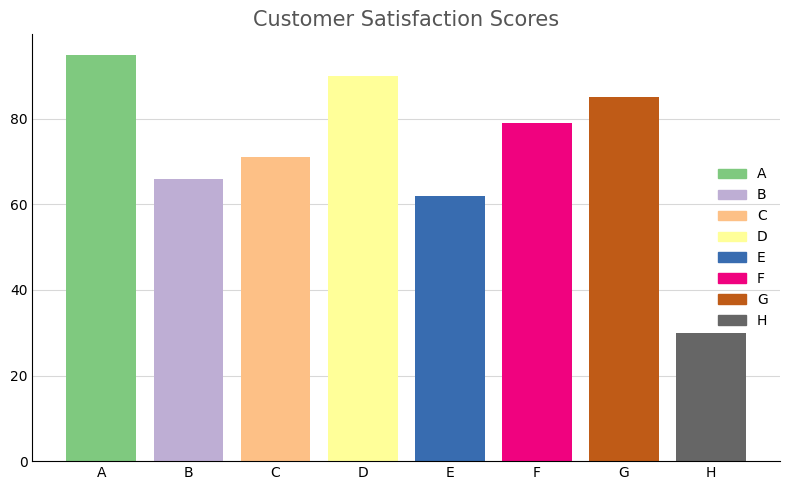

In [14]:
fig = render_bar_matplotlib(style=example_style, seed=7)
plt.show()



## 9. Test one image per individual parameter option

The testing functions below generate one chart for **every available code/value option of every parameter**. The saved image filenames include the library, tested parameter, original code, and decoded value, for example `matplotlib__title_present__1__true.png`.

By default, the full test suite saves directly under `barplots/images/matplotlib/`, `barplots/images/seaborn/`, `barplots/images/plotly/`, and `barplots/images/altair/`, matching the line-chart notebook output style.

For Altair and Plotly, this notebook now exports **PNG images** during the test run. It does **not** intentionally fall back to HTML.


In [15]:
def clean_bar_testing_folder(out_root: Path = BAR_TEST_OUT_ROOT):
    """Delete the old barplots output folder and recreate the line-style folder structure."""
    out_root = Path(out_root)
    if out_root.exists():
        shutil.rmtree(out_root)
    ensure_output_dirs(out_root)


def _parameter_test_summary_rows(metas: list[dict]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "chart_id": m.get("chart_id"),
            "library": m.get("library"),
            "tested_parameter": m.get("tested_parameter"),
            "tested_code": m.get("tested_code"),
            "tested_value": m.get("tested_value"),
            "image_path": m.get("image_path"),
            "table_path": m.get("table_path"),
            "rng_seed": m.get("rng_seed"),
        }
        for m in metas
    ])


def _execute_parameter_tests(
    out_root: Path,
    libraries: tuple[str, ...],
    summary_filename: str,
    error_filename: str,
    clean_first: bool = True,
    continue_on_error: bool = False,
    seed_start: int = 50_000,
) -> tuple[list[dict], list[dict]]:
    """
    Core helper used by both the Altair-only test and the all-libraries test.

    If clean_first=True, the old barplots output folder is deleted before regeneration.
    All images are saved in out_root / 'images' / <library>.
    """
    out_root = Path(out_root)
    if clean_first:
        clean_bar_testing_folder(out_root)
    else:
        ensure_output_dirs(out_root)

    metas: list[dict] = []
    errors: list[dict] = []
    seed = seed_start

    for library in libraries:
        for param_name, spec in STYLE_SPEC.items():
            for code_value, decoded_value in spec["codes"].items():
                forced_style = {param_name: decoded_value}
                filename_override = f"{library}__{param_name}__{code_value}__{decoded_value}"

                try:
                    meta = generate_bar(
                        library=library,
                        style=forced_style,
                        output_root=out_root,
                        seed=seed,
                        filename_override=filename_override,
                    )
                    meta["test_type"] = "direct_parameter_option"
                    meta["tested_parameter"] = param_name
                    meta["tested_code"] = code_value
                    meta["tested_value"] = decoded_value
                    metas.append(meta)
                except Exception as e:
                    error_record = {
                        "library": library,
                        "tested_parameter": param_name,
                        "tested_code": code_value,
                        "tested_value": decoded_value,
                        "rng_seed": seed,
                        "filename_override": safe_slug(filename_override),
                        "error_type": type(e).__name__,
                        "error_message": str(e),
                    }
                    errors.append(error_record)
                    if not continue_on_error:
                        error_df = pd.DataFrame(errors)
                        if not error_df.empty:
                            error_df.to_csv(out_root / "metadata" / error_filename, index=False)
                        raise
                finally:
                    seed += 1

    summary_df = _parameter_test_summary_rows(metas)
    summary_df.to_csv(out_root / "metadata" / summary_filename, index=False)

    error_df = pd.DataFrame(errors)
    error_df.to_csv(out_root / "metadata" / error_filename, index=False)
    return metas, errors


def run_altair_parameter_tests(
    out_root: Path = BAR_TEST_OUT_ROOT,
    clean_first: bool = True,
    continue_on_error: bool = True,
) -> tuple[list[dict], list[dict]]:
    """
    Generate one Altair chart for every bar-chart parameter option.

    Saved outputs:
    - images:   out_root / 'images' / 'altair'
    - tables:   out_root / 'tables'
    - metadata: out_root / 'metadata'
    """
    return _execute_parameter_tests(
        out_root=out_root,
        libraries=("altair",),
        summary_filename="altair_bar_parameter_test_summary.csv",
        error_filename="altair_bar_parameter_test_errors.csv",
        clean_first=clean_first,
        continue_on_error=continue_on_error,
        seed_start=80_000,
    )


def run_all_parameter_tests(
    out_root: Path = BAR_TEST_OUT_ROOT,
    clean_first: bool = True,
    continue_on_error: bool = False,
    libraries: tuple[str, ...] | None = None,
) -> tuple[list[dict], list[dict]]:
    """
    Generate one test chart for every parameter option for all requested libraries.

    Saved outputs:
    - images:   out_root / 'images' / 'matplotlib' | 'seaborn' | 'plotly' | 'altair'
    - tables:   out_root / 'tables'
    - metadata: out_root / 'metadata'
    """
    if libraries is None:
        libraries = ("matplotlib", "seaborn", "plotly", "altair") if sns is not None else ("matplotlib", "plotly", "altair")
    return _execute_parameter_tests(
        out_root=out_root,
        libraries=libraries,
        summary_filename="bar_parameter_test_summary.csv",
        error_filename="bar_parameter_test_errors.csv",
        clean_first=clean_first,
        continue_on_error=continue_on_error,
        seed_start=50_000,
    )


def summarize_test_coverage(metas: list[dict]) -> pd.DataFrame:
    rows = []
    meta_df = pd.DataFrame(metas)
    if meta_df.empty:
        return pd.DataFrame(columns=["parameter", "library", "expected_options", "generated_options", "complete"])
    for param, spec in STYLE_SPEC.items():
        expected = len(spec["codes"])
        for library in sorted(meta_df["library"].dropna().unique()):
            found = meta_df[(meta_df["tested_parameter"] == param) & (meta_df["library"] == library)]["tested_code"].nunique()
            rows.append({"parameter": param, "library": library, "expected_options": expected, "generated_options": found, "complete": found == expected})
    return pd.DataFrame(rows)



### 9A. Parameter tests for errors




In [18]:
def run_library_parameter_tests(
    library: str,
    out_root: Path = BAR_TEST_OUT_ROOT,
    clean_first: bool = True,
    continue_on_error: bool = True,
    seed_start: int = 80_000,
) -> tuple[list[dict], list[dict]]:
    """
    Generate one chart for every bar-chart parameter option for one library only.

    Example:
        run_library_parameter_tests("matplotlib")
        run_library_parameter_tests("seaborn")
        run_library_parameter_tests("plotly")
        run_library_parameter_tests("altair")
    """
    return _execute_parameter_tests(
        out_root=out_root,
        libraries=(library,),
        summary_filename=f"{library}_bar_parameter_test_summary.csv",
        error_filename=f"{library}_bar_parameter_test_errors.csv",
        clean_first=clean_first,
        continue_on_error=continue_on_error,
        seed_start=seed_start,
    )

In [20]:
matplotlib_test_metas, matplotlib_test_errors = run_library_parameter_tests(
    library="matplotlib",
    out_root=BAR_TEST_OUT_ROOT,
    clean_first=True,
    continue_on_error=True,
)

print(f"Matplotlib-only successes: {len(matplotlib_test_metas)}")
print(f"Matplotlib-only errors: {len(matplotlib_test_errors)}")
print(f"Matplotlib image folder: {BAR_TEST_OUT_ROOT / 'images' / 'matplotlib'}")

pd.DataFrame(matplotlib_test_metas).head(), pd.DataFrame(matplotlib_test_errors).head()

Matplotlib-only successes: 76
Matplotlib-only errors: 0
Matplotlib image folder: C:\Users\Michelle\I2R\notebooks\outputs\generated\barplots\images\matplotlib


(                           chart_id     library  \
 0    matplotlib_is_vertical_0_false  matplotlib   
 1     matplotlib_is_vertical_1_true  matplotlib   
 2  matplotlib_title_present_0_false  matplotlib   
 3   matplotlib_title_present_1_true  matplotlib   
 4  matplotlib_title_location_0_none  matplotlib   
 
                                                style  rows  \
 0  {'is_vertical': False, 'title_present': True, ...     3   
 1  {'is_vertical': True, 'title_present': True, '...     3   
 2  {'is_vertical': True, 'title_present': False, ...     3   
 3  {'is_vertical': True, 'title_present': True, '...     3   
 4  {'is_vertical': True, 'title_present': True, '...     3   
 
                                           image_path  \
 0  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 1  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 2  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 3  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 4  C:\Users\Michelle

In [27]:
seaborn_test_metas, seaborn_test_errors = run_library_parameter_tests(
    library="seaborn",
    out_root=BAR_TEST_OUT_ROOT,
    clean_first=True,
    continue_on_error=False,
)

print(f"Seaborn-only successes: {len(seaborn_test_metas)}")
print(f"Seaborn-only errors: {len(seaborn_test_errors)}")
print(f"Seaborn image folder: {BAR_TEST_OUT_ROOT / 'images' / 'seaborn'}")

pd.DataFrame(seaborn_test_metas).head(), pd.DataFrame(seaborn_test_errors).head()

Seaborn-only successes: 76
Seaborn-only errors: 0
Seaborn image folder: C:\Users\Michelle\I2R\notebooks\outputs\generated\barplots\images\seaborn


(                        chart_id  library  \
 0    seaborn_is_vertical_0_false  seaborn   
 1     seaborn_is_vertical_1_true  seaborn   
 2  seaborn_title_present_0_false  seaborn   
 3   seaborn_title_present_1_true  seaborn   
 4  seaborn_title_location_0_none  seaborn   
 
                                                style  rows  \
 0  {'is_vertical': False, 'title_present': True, ...     3   
 1  {'is_vertical': True, 'title_present': True, '...     3   
 2  {'is_vertical': True, 'title_present': False, ...     3   
 3  {'is_vertical': True, 'title_present': True, '...     3   
 4  {'is_vertical': True, 'title_present': True, '...     3   
 
                                           image_path  \
 0  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 1  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 2  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 3  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 4  C:\Users\Michelle\I2R\notebooks\outputs\genera...   


In [23]:
plotly_test_metas, plotly_test_errors = run_library_parameter_tests(
    library="plotly",
    out_root=BAR_TEST_OUT_ROOT,
    clean_first=True,
    continue_on_error=True,
)

print(f"Plotly-only successes: {len(plotly_test_metas)}")
print(f"Plotly-only errors: {len(plotly_test_errors)}")
print(f"Plotly image folder: {BAR_TEST_OUT_ROOT / 'images' / 'plotly'}")

pd.DataFrame(plotly_test_metas).head(), pd.DataFrame(plotly_test_errors).head()

Plotly-only successes: 76
Plotly-only errors: 0
Plotly image folder: C:\Users\Michelle\I2R\notebooks\outputs\generated\barplots\images\plotly


(                       chart_id library  \
 0    plotly_is_vertical_0_false  plotly   
 1     plotly_is_vertical_1_true  plotly   
 2  plotly_title_present_0_false  plotly   
 3   plotly_title_present_1_true  plotly   
 4  plotly_title_location_0_none  plotly   
 
                                                style  rows  \
 0  {'is_vertical': False, 'title_present': True, ...     3   
 1  {'is_vertical': True, 'title_present': True, '...     3   
 2  {'is_vertical': True, 'title_present': False, ...     3   
 3  {'is_vertical': True, 'title_present': True, '...     3   
 4  {'is_vertical': True, 'title_present': True, '...     3   
 
                                           image_path  \
 0  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 1  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 2  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 3  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 4  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 
          

In [30]:
altair_test_metas, altair_test_errors = run_library_parameter_tests(
    library="altair",
    out_root=BAR_TEST_OUT_ROOT,
    clean_first=True,
    continue_on_error=False,
)

print(f"Altair-only successes: {len(altair_test_metas)}")
print(f"Altair-only errors: {len(altair_test_errors)}")
print(f"Altair image folder: {BAR_TEST_OUT_ROOT / 'images' / 'altair'}")

pd.DataFrame(altair_test_metas).head(), pd.DataFrame(altair_test_errors).head()

Altair-only successes: 76
Altair-only errors: 0
Altair image folder: C:\Users\Michelle\I2R\notebooks\outputs\generated\barplots\images\altair


(                       chart_id library  \
 0    altair_is_vertical_0_false  altair   
 1     altair_is_vertical_1_true  altair   
 2  altair_title_present_0_false  altair   
 3   altair_title_present_1_true  altair   
 4  altair_title_location_0_none  altair   
 
                                                style  rows  \
 0  {'is_vertical': False, 'title_present': True, ...     3   
 1  {'is_vertical': True, 'title_present': True, '...     3   
 2  {'is_vertical': True, 'title_present': False, ...     3   
 3  {'is_vertical': True, 'title_present': True, '...     3   
 4  {'is_vertical': True, 'title_present': True, '...     3   
 
                                           image_path  \
 0  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 1  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 2  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 3  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 4  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 
          


### 9B. All-libraries parameter test

This cell deletes the old `barplots` output folder first, then regenerates the full test suite for Matplotlib, Seaborn/Matplotlib, Plotly, and Altair. All outputs are saved under `barplots/`, specifically `barplots/images/matplotlib/`, `barplots/images/seaborn/`, `barplots/images/plotly/`, and `barplots/images/altair/`.


In [31]:

direct_metas, direct_errors = run_all_parameter_tests(
    out_root=BAR_TEST_OUT_ROOT,
    clean_first=True,
    continue_on_error=True,
)

print(f"All-library successes: {len(direct_metas)}")
print(f"All-library errors: {len(direct_errors)}")
print(f"Matplotlib image folder: {BAR_TEST_OUT_ROOT / 'images' / 'matplotlib'}")
print(f"Seaborn image folder: {BAR_TEST_OUT_ROOT / 'images' / 'seaborn'}")
print(f"Plotly image folder: {BAR_TEST_OUT_ROOT / 'images' / 'plotly'}")
print(f"Altair image folder: {BAR_TEST_OUT_ROOT / 'images' / 'altair'}")

coverage = summarize_test_coverage(direct_metas)
coverage.to_csv(BAR_TEST_OUT_ROOT / 'metadata' / 'bar_parameter_test_coverage.csv', index=False)

len(direct_metas), pd.DataFrame(direct_metas).head(), coverage[~coverage['complete']], pd.DataFrame(direct_errors).head()


All-library successes: 304
All-library errors: 0
Matplotlib image folder: C:\Users\Michelle\I2R\notebooks\outputs\generated\barplots\images\matplotlib
Seaborn image folder: C:\Users\Michelle\I2R\notebooks\outputs\generated\barplots\images\seaborn
Plotly image folder: C:\Users\Michelle\I2R\notebooks\outputs\generated\barplots\images\plotly
Altair image folder: C:\Users\Michelle\I2R\notebooks\outputs\generated\barplots\images\altair


(304,
                            chart_id     library  \
 0    matplotlib_is_vertical_0_false  matplotlib   
 1     matplotlib_is_vertical_1_true  matplotlib   
 2  matplotlib_title_present_0_false  matplotlib   
 3   matplotlib_title_present_1_true  matplotlib   
 4  matplotlib_title_location_0_none  matplotlib   
 
                                                style  rows  \
 0  {'is_vertical': False, 'title_present': True, ...     3   
 1  {'is_vertical': True, 'title_present': True, '...     3   
 2  {'is_vertical': True, 'title_present': False, ...     3   
 3  {'is_vertical': True, 'title_present': True, '...     3   
 4  {'is_vertical': True, 'title_present': True, '...     3   
 
                                           image_path  \
 0  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 1  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 2  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 3  C:\Users\Michelle\I2R\notebooks\outputs\genera...   
 4  C:\Users\Mi

## 10. Original bar-chart notebook code preserved

These cells preserve the original separate notebook code for traceability. The Python code is stored as strings to avoid overwriting the integrated functions above. The ggplot code is stored as an R script string and can be written out with the following cell.

In [ ]:
matplotlib_original_code = 'import matplotlib.pyplot as plt\nimport matplotlib.patches as mpatches\nimport matplotlib.cm as cm\nimport pandas as pd\nimport numpy as np\nimport random\nimport string\n\ndef get_random_data(n=10):\n    """Generates a random dataframe for plotting."""\n    categories = list(string.ascii_uppercase)[:n]\n    values = np.random.randint(10, 100, size=n)\n    return pd.DataFrame({\'Category\': categories, \'Value\': values})\n\ndef generate_random_matplotlib_chart():\n    # --- 1. Generate Data ---\n    df = get_random_data(random.randint(5, 12))\n\n    # Clear previous plots\n    plt.clf()\n    fig, ax = plt.subplots(figsize=(8, 5))\n\n    # --- 2. Determine Random Parameters ---\n    is_vertical = random.random() < 0.74\n    has_title = random.random() < 0.61\n    title_props = {}\n    title_text_str = ""\n\n    # Random Title Generator\n    possible_titles = [\n        "Sales Distribution 2024", "Regional Population Metrics", "Customer Satisfaction Scores",\n        "Inventory Levels by Category", "Quarterly Revenue Growth", "Survey Response Analysis",\n        "Average Temperature Data", "Product Performance Review", "Market Share Distribution",\n        "Website Traffic Sources", "Employee Engagement Indices", "Monthly Expense Breakdown"\n    ]\n\n    base_title_text = random.choice(possible_titles)\n\n    if has_title:\n        title_props[\'loc\'] = \'center\' if random.random() < 0.79 else \'left\'\n        title_props[\'color\'] = \'black\' if random.random() < 0.60 else random.choice([\'#555555\', \'#3f51b5\', \'#c62828\'])\n        title_props[\'fontsize\'] = random.randint(12, 18) if random.random() < 0.80 else random.randint(20, 24)\n\n        if random.random() < 0.02:\n            title_text_str = f"{base_title_text}\\nDetailed Overview & Analysis"\n        else:\n            title_text_str = base_title_text\n\n    has_view_outline = random.random() < 0.10\n\n    r_grid = random.random()\n    grid_axis = None\n    if r_grid < 0.52:\n        grid_axis = \'y\' if is_vertical else \'x\'\n    elif r_grid < 0.65:\n        grid_axis = \'both\'\n\n    # Axis Labels\n    r_lx = random.random()\n    if r_lx < 0.92: x_angle, x_labels_on = 0, True\n    elif r_lx < 0.96: x_angle, x_labels_on = 45, True\n    elif r_lx < 0.97: x_angle, x_labels_on = 90, True\n    else: x_angle, x_labels_on = 0, False\n\n    r_ly = random.random()\n    if r_ly < 0.98: y_angle, y_labels_on = 0, True\n    elif r_ly < 0.99: y_angle, y_labels_on = 90, True\n    else: y_angle, y_labels_on = 0, False\n\n    label_color = \'black\'\n    if random.random() < 0.15:\n        label_color = random.choice([\'#666666\', \'#1f77b4\', \'#d62728\'])\n\n    # --- 3. Color Logic ---\n    is_uniform_color = random.random() < 0.50\n    color_palette_hex = [\n        \'#1f77b4\', \'#ff7f0e\', \'#2ca02c\', \'#d62728\', \'#9467bd\',\n        \'#8c564b\', \'#e377c2\', \'#7f7f7f\', \'#bcbd22\', \'#17becf\',\n        \'#393b79\', \'#637939\', \'#8c6d31\', \'#843c39\', \'black\'\n    ]\n\n    bar_colors = []\n\n    # Map scheme names to Matplotlib colormaps\n    schemes_map = {\n        \'tableau10\': \'tab10\', \'set2\': \'Set2\', \'accent\': \'Accent\',\n        \'category10\': \'tab10\', \'dark2\': \'Dark2\'\n    }\n\n    if is_uniform_color:\n        chosen_color = random.choice(color_palette_hex)\n        bar_colors = [chosen_color] * len(df)\n    else:\n        scheme_name = random.choice(list(schemes_map.keys()))\n        mpl_cmap_name = schemes_map[scheme_name]\n\n        # Get the colormap object\n        cmap = plt.get_cmap(mpl_cmap_name)\n\n        # Generate a color for each bar based on its index\n        # We use i % cmap.N to ensure we don\'t go out of bounds if N > colormap size\n        bar_colors = [cmap(i % cmap.N) for i in range(len(df))]\n\n    # --- 4. Bar Styles ---\n    bar_stroke = \'black\' if random.random() < 0.27 else \'none\'\n    stroke_width = 1 if bar_stroke == \'black\' else 0\n\n    bg_color = \'white\'\n    if random.random() < 0.03:\n        bg_color = \'#f0f0f0\'\n\n    # --- 5. Construct Chart (Pure Matplotlib) ---\n    if is_vertical:\n        ax.bar(\n            df[\'Category\'],\n            df[\'Value\'],\n            color=bar_colors,\n            edgecolor=bar_stroke,\n            linewidth=stroke_width\n        )\n    else:\n        ax.barh(\n            df[\'Category\'],\n            df[\'Value\'],\n            color=bar_colors,\n            edgecolor=bar_stroke,\n            linewidth=stroke_width\n        )\n\n    # --- Apply Styling ---\n    ax.set_facecolor(bg_color)\n    fig.patch.set_facecolor(bg_color)\n\n    if has_title:\n        ax.set_title(title_text_str, **title_props)\n\n    # Manual Spine Control (replacing sns.despine)\n    if not has_view_outline:\n        ax.spines[\'top\'].set_visible(False)\n        ax.spines[\'right\'].set_visible(False)\n        # Keep left/bottom unless you specifically wanted them gone too\n        ax.spines[\'left\'].set_visible(True)\n        ax.spines[\'bottom\'].set_visible(True)\n        ax.spines[\'left\'].set_color(\'black\')\n        ax.spines[\'bottom\'].set_color(\'black\')\n    else:\n        for spine in ax.spines.values():\n            spine.set_visible(True)\n            spine.set_color(\'black\')\n            spine.set_linewidth(1)\n\n    if grid_axis:\n        ax.grid(True, axis=grid_axis, linestyle=\'-\', alpha=0.3, color=\'gray\')\n        # Ensure grid is behind bars\n        ax.set_axisbelow(True)\n    else:\n        ax.grid(False)\n\n    # Label Handling\n    if x_labels_on:\n        plt.setp(ax.get_xticklabels(), rotation=x_angle, color=label_color)\n        ax.tick_params(axis=\'x\', colors=label_color)\n    else:\n        ax.set_xticklabels([])\n        ax.tick_params(axis=\'x\', length=0)\n\n    if y_labels_on:\n        plt.setp(ax.get_yticklabels(), rotation=y_angle, color=label_color)\n        ax.tick_params(axis=\'y\', colors=label_color)\n    else:\n        ax.set_yticklabels([])\n        ax.tick_params(axis=\'y\', length=0)\n\n    # --- Legend Logic (Manual) ---\n    has_legend = random.random() < 0.09\n\n    if has_legend and not is_uniform_color:\n        # Determine Legend Position\n        r_leg = random.random()\n        if r_leg < 0.33: legend_loc = \'center right\'\n        elif r_leg < 0.43: legend_loc = \'upper center\'\n        elif r_leg < 0.76: legend_loc = \'upper right\'\n        elif r_leg < 0.86: legend_loc = \'upper left\'\n        elif r_leg < 0.96: legend_loc = \'lower center\'\n        else: legend_loc = \'center right\'\n\n        legend_props = {}\n        if random.random() < 0.20:\n            legend_props[\'frameon\'] = True\n            legend_props[\'edgecolor\'] = \'black\'\n            legend_props[\'framealpha\'] = 1\n        else:\n            legend_props[\'frameon\'] = False\n\n        leg_title = "Category" if random.random() < 0.90 else None\n\n        # Create handles manually for the legend\n        # (Zip category names with the colors we generated earlier)\n        handles = [\n            mpatches.Patch(color=c, label=l)\n            for c, l in zip(bar_colors, df[\'Category\'])\n        ]\n\n        ax.legend(handles=handles, loc=legend_loc, title=leg_title, **legend_props)\n\n    return fig\n\n# --- Generate a Chart ---\nfig = generate_random_matplotlib_chart()\nplt.show()'

In [ ]:
seaborn_matplotlib_original_code = 'import seaborn as sns\nimport matplotlib.pyplot as plt\nimport pandas as pd\nimport numpy as np\nimport random\nimport string\n\ndef get_random_data(n=10):\n    """Generates a random dataframe for plotting."""\n    categories = list(string.ascii_uppercase)[:n]\n    values = np.random.randint(10, 100, size=n)\n    return pd.DataFrame({\'Category\': categories, \'Value\': values})\n\ndef generate_random_seaborn_chart():\n    # --- 1. Generate Data ---\n    df = get_random_data(random.randint(5, 12))\n\n    plt.clf()\n    fig, ax = plt.subplots(figsize=(8, 5))\n\n    # --- 2. Determine Random Parameters ---\n    is_vertical = random.random() < 0.74\n    has_title = random.random() < 0.61\n    title_props = {}\n    title_text_str = ""\n\n    # Random Title Generator\n    possible_titles = [\n        "Sales Distribution 2024", "Regional Population Metrics", "Customer Satisfaction Scores",\n        "Inventory Levels by Category", "Quarterly Revenue Growth", "Survey Response Analysis",\n        "Average Temperature Data", "Product Performance Review", "Market Share Distribution",\n        "Website Traffic Sources", "Employee Engagement Indices", "Monthly Expense Breakdown"\n    ]\n\n    base_title_text = random.choice(possible_titles)\n\n    if has_title:\n        title_props[\'loc\'] = \'center\' if random.random() < 0.79 else \'left\'\n        title_props[\'color\'] = \'black\' if random.random() < 0.60 else random.choice([\'#555555\', \'#3f51b5\', \'#c62828\'])\n        title_props[\'fontsize\'] = random.randint(12, 18) if random.random() < 0.80 else random.randint(20, 24)\n\n        if random.random() < 0.02:\n            title_text_str = f"{base_title_text}\\nDetailed Overview & Analysis"\n        else:\n            title_text_str = base_title_text\n\n    has_view_outline = random.random() < 0.10\n\n    r_grid = random.random()\n    grid_axis = None\n    if r_grid < 0.52:\n        grid_axis = \'y\' if is_vertical else \'x\'\n    elif r_grid < 0.65:\n        grid_axis = \'both\'\n\n    # Axis Labels\n    r_lx = random.random()\n    if r_lx < 0.92: x_angle, x_labels_on = 0, True\n    elif r_lx < 0.96: x_angle, x_labels_on = 45, True\n    elif r_lx < 0.97: x_angle, x_labels_on = 90, True\n    else: x_angle, x_labels_on = 0, False\n\n    r_ly = random.random()\n    if r_ly < 0.98: y_angle, y_labels_on = 0, True\n    elif r_ly < 0.99: y_angle, y_labels_on = 90, True\n    else: y_angle, y_labels_on = 0, False\n\n    label_color = \'black\'\n    if random.random() < 0.15:\n        label_color = random.choice([\'#666666\', \'#1f77b4\', \'#d62728\'])\n\n    # --- 3. Color Logic ---\n    is_uniform_color = random.random() < 0.50\n    color_palette_hex = [\n        \'#1f77b4\', \'#ff7f0e\', \'#2ca02c\', \'#d62728\', \'#9467bd\',\n        \'#8c564b\', \'#e377c2\', \'#7f7f7f\', \'#bcbd22\', \'#17becf\',\n        \'#393b79\', \'#637939\', \'#8c6d31\', \'#843c39\', \'black\'\n    ]\n\n    has_legend = random.random() < 0.09\n    legend_loc = \'best\'\n    legend_frame_on = False\n    legend_params = {}\n\n    if has_legend:\n        r_leg = random.random()\n        if r_leg < 0.33: legend_loc = \'center right\'\n        elif r_leg < 0.43: legend_loc = \'upper center\'\n        elif r_leg < 0.76: legend_loc = \'upper right\'\n        elif r_leg < 0.86: legend_loc = \'upper left\'\n        elif r_leg < 0.96: legend_loc = \'lower center\'\n        else: legend_loc = \'center right\'\n\n        if random.random() < 0.20:\n            legend_frame_on = True\n            legend_params[\'edgecolor\'] = \'black\'\n            legend_params[\'framealpha\'] = 1\n\n    plot_args = {}\n    schemes_map = {\n        \'tableau10\': \'tab10\', \'set2\': \'Set2\', \'accent\': \'Accent\',\n        \'category10\': \'tab10\', \'dark2\': \'Dark2\'\n    }\n\n    if is_uniform_color:\n        chosen_color = random.choice(color_palette_hex)\n        plot_args[\'color\'] = chosen_color\n    else:\n        scheme_name = random.choice(list(schemes_map.keys()))\n        plot_args[\'palette\'] = schemes_map[scheme_name]\n        plot_args[\'hue\'] = \'Category\'\n        plot_args[\'dodge\'] = False\n\n    # --- 4. Bar Styles (FIX IS HERE) ---\n    # Replaced \'transparent\' with \'none\'\n    bar_stroke = \'black\' if random.random() < 0.27 else \'none\'\n    stroke_width = 1 if bar_stroke == \'black\' else 0\n\n    plot_args[\'edgecolor\'] = bar_stroke\n    plot_args[\'linewidth\'] = stroke_width\n\n    bg_color = \'white\'\n    if random.random() < 0.03:\n        bg_color = \'#f0f0f0\'\n\n    # --- 5. Construct Chart ---\n    if is_vertical:\n        sns.barplot(data=df, x=\'Category\', y=\'Value\', ax=ax, **plot_args)\n        ax.set_xlabel(\'\')\n        ax.set_ylabel(\'\')\n    else:\n        sns.barplot(data=df, x=\'Value\', y=\'Category\', orient=\'h\', ax=ax, **plot_args)\n        ax.set_xlabel(\'\')\n        ax.set_ylabel(\'\')\n\n    # --- Apply Styling ---\n    ax.set_facecolor(bg_color)\n    fig.patch.set_facecolor(bg_color)\n\n    if has_title:\n        ax.set_title(title_text_str, **title_props)\n\n    if not has_view_outline:\n        sns.despine(ax=ax)\n    else:\n        for spine in ax.spines.values():\n            spine.set_visible(True)\n            spine.set_color(\'black\')\n            spine.set_linewidth(1)\n\n    if grid_axis:\n        ax.grid(True, axis=grid_axis, linestyle=\'-\', alpha=0.3, color=\'gray\')\n    else:\n        ax.grid(False)\n\n    if x_labels_on:\n        plt.setp(ax.get_xticklabels(), rotation=x_angle, color=label_color)\n        ax.tick_params(axis=\'x\', colors=label_color)\n    else:\n        ax.set_xticklabels([])\n        ax.tick_params(axis=\'x\', length=0)\n\n    if y_labels_on:\n        plt.setp(ax.get_yticklabels(), rotation=y_angle, color=label_color)\n        ax.tick_params(axis=\'y\', colors=label_color)\n    else:\n        ax.set_yticklabels([])\n        ax.tick_params(axis=\'y\', length=0)\n\n    if has_legend and not is_uniform_color:\n        leg_title = "Category" if random.random() < 0.90 else None\n        ax.legend(loc=legend_loc, title=leg_title, frameon=legend_frame_on, **legend_params)\n    else:\n        if ax.get_legend():\n            ax.legend_.remove()\n\n    return fig\n\n# --- Generate a Chart ---\nfig = generate_random_seaborn_chart()\nplt.show()'

In [ ]:
altair_original_code = 'import altair as alt\nimport pandas as pd\nimport numpy as np\nimport random\nimport string\n\ndef get_random_data(n=10):\n    """Generates a random dataframe for plotting."""\n    categories = list(string.ascii_uppercase)[:n]\n    values = np.random.randint(10, 100, size=n)\n    return pd.DataFrame({\'Category\': categories, \'Value\': values})\n\ndef generate_random_altair_chart():\n    # --- 1. Generate Data ---\n    df = get_random_data(random.randint(5, 12))\n\n    # --- 2. Determine Random Parameters ---\n\n    # Rule: 74% Qual on X (Vertical), 26% Qual on Y (Horizontal)\n    is_vertical = random.random() < 0.74\n\n    # Rule: 61% have title\n    has_title = random.random() < 0.61\n    title_props = {}\n\n    # Random Title Generator\n    possible_titles = [\n        "Sales Distribution 2024", "Regional Population Metrics", "Customer Satisfaction Scores",\n        "Inventory Levels by Category", "Quarterly Revenue Growth", "Survey Response Analysis",\n        "Average Temperature Data", "Product Performance Review", "Market Share Distribution",\n        "Website Traffic Sources", "Employee Engagement Indices", "Monthly Expense Breakdown"\n    ]\n\n    # Select a random title text\n    base_title_text = random.choice(possible_titles)\n\n    # Logic to handle subtitle structure if needed\n    if has_title:\n        title_props[\'anchor\'] = \'middle\' if random.random() < 0.79 else \'start\'\n        title_props[\'color\'] = \'black\' if random.random() < 0.60 else random.choice([\'#555555\', \'#3f51b5\', \'#c62828\'])\n\n        if random.random() < 0.80:\n            title_props[\'fontSize\'] = random.randint(12, 18)\n        else:\n            title_props[\'fontSize\'] = random.randint(20, 24)\n\n        # 2% Chance of Subtitle\n        if random.random() < 0.02:\n            title_text = {"text": base_title_text, "subtitle": "Detailed Overview & Analysis"}\n        else:\n            title_text = base_title_text\n\n    # Rule: 10% plot outline\n    has_view_outline = random.random() < 0.10\n\n    # Rule: Gridlines (52% Quant, 13% Both)\n    r_grid = random.random()\n    if r_grid < 0.52:\n        grid_x = False if is_vertical else True\n        grid_y = True if is_vertical else False\n    elif r_grid < 0.65:\n        grid_x, grid_y = True, True\n    else:\n        grid_x, grid_y = False, False\n\n    # Rule: Axis Labels\n    r_lx = random.random()\n    if r_lx < 0.92: x_angle, x_labels = 0, True\n    elif r_lx < 0.96: x_angle, x_labels = -45, True\n    elif r_lx < 0.97: x_angle, x_labels = -90, True\n    else: x_angle, x_labels = 0, False\n\n    r_ly = random.random()\n    if r_ly < 0.98: y_angle, y_labels = 0, True\n    elif r_ly < 0.99: y_angle, y_labels = -90, True\n    else: y_angle, y_labels = 0, False\n\n    label_color = \'black\'\n    if random.random() < 0.15:\n        label_color = random.choice([\'#666666\', \'#1f77b4\', \'#d62728\'])\n\n    # --- 3. Color Logic (50% Uniform / 50% Varied) ---\n    is_uniform_color = random.random() < 0.50\n\n    color_palette = [\n        \'#1f77b4\', \'#ff7f0e\', \'#2ca02c\', \'#d62728\', \'#9467bd\',\n        \'#8c564b\', \'#e377c2\', \'#7f7f7f\', \'#bcbd22\', \'#17becf\',\n        \'#393b79\', \'#637939\', \'#8c6d31\', \'#843c39\', \'black\'\n    ]\n\n    has_legend = random.random() < 0.09\n    legend_props = {}\n\n    if has_legend:\n        r_leg = random.random()\n        if r_leg < 0.33: legend_pos = \'right\'\n        elif r_leg < 0.43: legend_pos = \'top\'\n        elif r_leg < 0.76: legend_pos = \'top-right\'\n        elif r_leg < 0.86: legend_pos = \'top-left\'\n        elif r_leg < 0.96: legend_pos = \'bottom\'\n        else: legend_pos = \'right\'\n\n        legend_props[\'orient\'] = legend_pos\n        if random.random() >= 0.10: legend_props[\'title\'] = None\n        if random.random() < 0.20:\n            legend_props[\'strokeColor\'] = \'black\'\n            legend_props[\'cornerRadius\'] = 0\n            legend_props[\'padding\'] = 10\n\n    if is_uniform_color:\n        chosen_color = random.choice(color_palette)\n        color_encode = alt.value(chosen_color)\n    else:\n        scheme = random.choice([\'tableau10\', \'set2\', \'accent\', \'category10\', \'dark2\'])\n        leg_obj = alt.Legend(**legend_props) if has_legend else None\n        color_encode = alt.Color(\'Category\', scale=alt.Scale(scheme=scheme), legend=leg_obj)\n\n    # --- 4. Bar Styles ---\n\n    # 9% Rounded Corners\n    corner_radius = 4 if random.random() < 0.09 else 0\n\n    bar_stroke = \'black\' if random.random() < 0.27 else \'transparent\'\n\n    bg_color = \'white\'\n    if random.random() < 0.03:\n        bg_color = \'#f0f0f0\'\n\n    # --- 5. Construct Chart ---\n\n    mark_args = {\n        \'cornerRadiusEnd\': corner_radius,\n        \'stroke\': bar_stroke,\n        \'strokeWidth\': 1 if bar_stroke == \'black\' else 0\n    }\n\n    x_axis_obj = alt.Axis(labels=x_labels, labelAngle=x_angle, labelColor=label_color, title=None, grid=grid_x)\n    y_axis_obj = alt.Axis(labels=y_labels, labelAngle=y_angle, labelColor=label_color, title=None, grid=grid_y)\n\n    if is_vertical:\n        x_encode = alt.X(\'Category\', axis=x_axis_obj)\n        y_encode = alt.Y(\'Value\', axis=y_axis_obj)\n    else:\n        x_encode = alt.X(\'Value\', axis=x_axis_obj)\n        y_encode = alt.Y(\'Category\', axis=y_axis_obj)\n\n    chart = alt.Chart(df).mark_bar(**mark_args).encode(\n        x=x_encode,\n        y=y_encode,\n        color=color_encode\n    )\n\n    if has_title:\n        chart = chart.properties(title=alt.TitleParams(text=title_text, **title_props))\n\n    chart = chart.configure_view(\n        stroke=\'black\' if has_view_outline else \'transparent\',\n        strokeWidth=1,\n        fill=bg_color\n    )\n\n    return chart\n\n# --- Generate a Chart ---\nchart = generate_random_altair_chart()\nchart.display()'

In [ ]:
ggplot_original_r_code = 'library(ggplot2)\nlibrary(dplyr)\nlibrary(stringr)\n\n# --- 1. Generate Data ---\nget_random_data <- function(n = 10) {\n  # Generates a random dataframe for plotting\n  categories <- LETTERS[1:n]\n  values <- sample(10:100, n, replace = TRUE)\n  return(data.frame(Category = categories, Value = values))\n}\n\ngenerate_random_ggplot <- function() {\n\n  # Generate Data (Random n between 5 and 12)\n  df <- get_random_data(sample(5:12, 1))\n\n  # --- 2. Determine Random Parameters ---\n\n  # Rule: 74% Vertical, 26% Horizontal\n  is_vertical <- runif(1) < 0.74\n\n  # Rule: 61% have title\n  has_title <- runif(1) < 0.61\n  title_text <- NULL\n  subtitle_text <- NULL\n\n  # Theme element placeholders\n  plot_title_element <- element_text()\n\n  possible_titles <- c(\n    "Sales Distribution 2024", "Regional Population Metrics", "Customer Satisfaction Scores",\n    "Inventory Levels by Category", "Quarterly Revenue Growth", "Survey Response Analysis",\n    "Average Temperature Data", "Product Performance Review", "Market Share Distribution",\n    "Website Traffic Sources", "Employee Engagement Indices", "Monthly Expense Breakdown"\n  )\n\n  if (has_title) {\n    base_title <- sample(possible_titles, 1)\n\n    # Title Alignment\n    # Anchor middle (hjust 0.5) 79%, start (hjust 0) 21%\n    t_hjust <- if (runif(1) < 0.79) 0.5 else 0\n\n    # Title Color\n    if (runif(1) < 0.60) {\n      t_color <- "black"\n    } else {\n      t_color <- sample(c(\'#555555\', \'#3f51b5\', \'#c62828\'), 1)\n    }\n\n    # Title Size\n    if (runif(1) < 0.80) {\n      t_size <- sample(12:18, 1)\n    } else {\n      t_size <- sample(20:24, 1)\n    }\n\n    # 2% Chance of Subtitle\n    if (runif(1) < 0.02) {\n      title_text <- base_title\n      subtitle_text <- "Detailed Overview & Analysis"\n    } else {\n      title_text <- base_title\n    }\n\n    plot_title_element <- element_text(\n      hjust = t_hjust,\n      color = t_color,\n      size = t_size,\n      face = "bold" # Ggplot titles look better bold usually, optional\n    )\n  }\n\n  # Rule: 10% plot outline\n  has_view_outline <- runif(1) < 0.10\n\n  # Rule: Gridlines (52% Quant, 13% Both)\n  # In Altair/Python logic:\n  # If Vertical: Quant is Y axis. If Horizontal: Quant is X axis.\n  r_grid <- runif(1)\n  show_grid_x <- FALSE\n  show_grid_y <- FALSE\n\n  if (r_grid < 0.52) {\n    if (is_vertical) show_grid_y <- TRUE else show_grid_x <- TRUE\n  } else if (r_grid < 0.65) {\n    show_grid_x <- TRUE\n    show_grid_y <- TRUE\n  }\n  # Else both False\n\n  # Rule: Axis Labels\n  # X Axis Logic\n  r_lx <- runif(1)\n  x_angle <- 0\n  show_x_labels <- TRUE\n\n  if (r_lx < 0.92) { x_angle <- 0 }\n  else if (r_lx < 0.96) { x_angle <- 315 } # -45 degrees in ggplot is often treated as 315 or 45 w/ hjust\n  else if (r_lx < 0.97) { x_angle <- 270 } # -90 degrees\n  else { show_x_labels <- FALSE }\n\n  # Y Axis Logic\n  r_ly <- runif(1)\n  y_angle <- 0\n  show_y_labels <- TRUE\n\n  if (r_ly < 0.98) { y_angle <- 0 }\n  else if (r_ly < 0.99) { y_angle <- 270 }\n  else { show_y_labels <- FALSE }\n\n  label_color <- "black"\n  if (runif(1) < 0.15) {\n    label_color <- sample(c(\'#666666\', \'#1f77b4\', \'#d62728\'), 1)\n  }\n\n  # --- 3. Color Logic (50% Uniform / 50% Varied) ---\n  is_uniform_color <- runif(1) < 0.50\n\n  color_palette_hex <- c(\n    \'#1f77b4\', \'#ff7f0e\', \'#2ca02c\', \'#d62728\', \'#9467bd\',\n    \'#8c564b\', \'#e377c2\', \'#7f7f7f\', \'#bcbd22\', \'#17becf\',\n    \'#393b79\', \'#637939\', \'#8c6d31\', \'#843c39\', \'black\'\n  )\n\n  # Legend Logic\n  has_legend <- runif(1) < 0.09\n  legend_pos <- "none"\n  legend_box_background <- element_blank()\n\n  if (has_legend) {\n    r_leg <- runif(1)\n    if (r_leg < 0.33) legend_pos <- "right"\n    else if (r_leg < 0.43) legend_pos <- "top"\n    # ggplot doesn\'t have exact top-right/top-left keywords, using approximation or standard\n    else if (r_leg < 0.76) legend_pos <- c(0.9, 0.9) # inside top right\n    else if (r_leg < 0.86) legend_pos <- c(0.1, 0.9) # inside top left\n    else if (r_leg < 0.96) legend_pos <- "bottom"\n    else legend_pos <- "right"\n\n    # Legend Border randomization\n    if (runif(1) < 0.20) {\n      legend_box_background <- element_rect(color = "black", fill = NA)\n    }\n  }\n\n  # --- 4. Bar Styles ---\n  # Rounded corners are excluded as requested.\n\n  bar_stroke_color <- if (runif(1) < 0.27) "black" else NA\n  bar_stroke_size <- if (!is.na(bar_stroke_color)) 0.5 else 0 # ggplot size is slightly different scale than altair\n\n  bg_color <- "white"\n  if (runif(1) < 0.03) bg_color <- "#f0f0f0"\n\n  # --- 5. Construct Chart ---\n\n  # Orientation Mapping\n  if (is_vertical) {\n    p <- ggplot(df, aes(x = Category, y = Value))\n    # If vertical, X needs the angle rotation logic\n    final_x_angle <- x_angle\n    final_y_angle <- y_angle\n  } else {\n    p <- ggplot(df, aes(y = Category, x = Value))\n    # If horizontal (coord_flip logic essentially), the "X" axis visually is Values\n    # But in ggplot aes mapping y=Category, the Y axis text elements control Category labels.\n    # To maintain the logic: The Category axis gets the rotation logic defined by x_angle/x_labels vars?\n    # In the original script: x_axis_obj is always X(\'Category\') if vertical, X(\'Value\') if horizontal.\n    # Let\'s map strict visual correspondence to the random vars generated:\n    # If Vertical: Category is X (use x vars), Value is Y (use y vars).\n    # If Horizontal: Value is X (use x vars), Category is Y (use y vars).\n    final_x_angle <- x_angle\n    final_y_angle <- y_angle\n  }\n\n  # Color & Geom\n  if (is_uniform_color) {\n    chosen_color <- sample(color_palette_hex, 1)\n    p <- p + geom_bar(stat = "identity", fill = chosen_color,\n                      color = bar_stroke_color, linewidth = bar_stroke_size)\n    legend_pos <- "none" # Force no legend if uniform\n  } else {\n    # Varied Color\n    schemes <- c("Set2", "Accent", "Dark2", "Paired", "Set1") # Mapping approximate RColorBrewer schemes\n    chosen_scheme <- sample(schemes, 1)\n\n    # We must add fill=Category to aes\n    if (is_vertical) {\n      p <- ggplot(df, aes(x = Category, y = Value, fill = Category))\n    } else {\n      p <- ggplot(df, aes(y = Category, x = Value, fill = Category))\n    }\n\n    p <- p + geom_bar(stat = "identity", color = bar_stroke_color, linewidth = bar_stroke_size) +\n      scale_fill_brewer(palette = chosen_scheme)\n  }\n\n  # Labels and Titles\n  p <- p + labs(title = title_text, subtitle = subtitle_text, x = NULL, y = NULL)\n\n  # Theme Construction\n  t <- theme_minimal() +\n    theme(\n      # Backgrounds\n      panel.background = element_rect(fill = bg_color, color = NA),\n      plot.background = element_rect(fill = bg_color, color = NA),\n\n      # Outline (View Stroke)\n      panel.border = if (has_view_outline) element_rect(color = "black", fill = NA, size = 1) else element_blank(),\n\n      # Grid Lines\n      panel.grid.major.x = if (show_grid_x) element_line(color = "lightgrey") else element_blank(),\n      panel.grid.minor.x = element_blank(),\n      panel.grid.major.y = if (show_grid_y) element_line(color = "lightgrey") else element_blank(),\n      panel.grid.minor.y = element_blank(),\n\n      # Axis Labels (Visibility and Color)\n      axis.text.x = if (show_x_labels) element_text(angle = final_x_angle, color = label_color, hjust = if(final_x_angle!=0) 1 else 0.5) else element_blank(),\n      axis.text.y = if (show_y_labels) element_text(angle = final_y_angle, color = label_color) else element_blank(),\n\n      # Title\n      plot.title = plot_title_element,\n      plot.subtitle = element_text(hjust = if(runif(1)<0.79) 0.5 else 0),\n\n      # Legend\n      legend.position = legend_pos,\n      legend.background = legend_box_background,\n      legend.title = if (runif(1) >= 0.10) element_blank() else element_text()\n    )\n\n  p <- p + t\n  return(p)\n}\n\n# --- Generate a Chart ---\nchart <- generate_random_ggplot()\nprint(chart)'
Path('ggplot_original_reference.R').write_text(ggplot_original_r_code)
'ggplot_original_reference.R'